# 🔩 GC10-DET — Treinamento com Classe OOD (Negativa)

**Problema identificado:** o modelo atual classifica imagens completamente fora do domínio 
(ex: dashboards, fotografias, documentos) como defeitos de aço com alta confiança.  
**Solução:** adicionar uma 11ª classe `negative` para que o modelo aprenda a rejeitar 
imagens que não são chapas de aço.

### Arquitetura
- **Classificador:** EfficientNetV2-S com 11 saídas (10 defeitos + 1 negativa)
- **Detector:** YOLOv8 (treinado separadamente — não é afetado por esse notebook)

### Estrutura esperada de diretórios
```
projeto/
├── images/images/
│   ├── punching_hole/   *.jpg
│   ├── welding_line/    *.jpg
│   ├── crescent_gap/    *.jpg
│   ├── ...              (10 classes de defeito)
│   └── waist_folding/   *.jpg
├── images/negative/     ← será criado pelo script de coleta
│   └── *.jpg            (imagens OOD coletadas)
├── gc10det_cls_best.pt  ← modelo base (10 classes)
└── este_notebook.ipynb
```

## 0. Instalação de dependências

In [1]:
!pip install torch torchvision albumentations scikit-learn pillow tqdm matplotlib seaborn --quiet

/bin/bash: /home/cesarmacieira/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)


## 1. Imports e configuração

In [2]:
import json
import random
import sys
from collections import Counter
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision.models import EfficientNet_V2_S_Weights, efficientnet_v2_s
from tqdm.notebook import tqdm

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5090 Laptop GPU
VRAM    : 25.7 GB


In [3]:
# ─── CONFIGURE AQUI ───────────────────────────────────────────────────────────
BASE_DIR        = Path(".")                          # pasta raiz do projeto
IMAGES_DIR      = BASE_DIR / "images" / "images"     # imagens de defeitos
NEG_DIR         = BASE_DIR / "images" / "negative"   # imagens negativas (OOD)
CHECKPOINT_IN   = BASE_DIR / "gc10det_cls_best.pt"   # modelo base (10 classes)
CHECKPOINT_OUT  = BASE_DIR / "gc10det_cls_ood.pt"    # modelo treinado (11 classes)
META_OUT        = BASE_DIR / "detection_metadata.json"

# Hiperparâmetros
EPOCHS       = 30
BATCH_SIZE   = 32
LR           = 2e-4      # cabeça de classificação
LR_BACKBONE  = 5e-5      # backbone (LR menor — já pré-treinado)
WEIGHT_DECAY = 1e-4
SEED         = 13

# Classes
DEFECT_CLASSES = [
    "punching_hole", "welding_line", "crescent_gap", "water_spot", "oil_spot",
    "silk_spot", "inclusion", "rolled_pit", "crease", "waist_folding",
]
CLASS_NAMES   = DEFECT_CLASSES + ["negative"]
N_CLASSES     = len(CLASS_NAMES)   # 11
OOD_CLASS_IDX = 10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Dispositivo : {DEVICE}")
print(f"Classes     : {CLASS_NAMES}")
print(f"N classes   : {N_CLASSES}")

Dispositivo : cuda
Classes     : ['punching_hole', 'welding_line', 'crescent_gap', 'water_spot', 'oil_spot', 'silk_spot', 'inclusion', 'rolled_pit', 'crease', 'waist_folding', 'negative']
N classes   : 11


## 2. Verificação das imagens negativas

Antes de treinar, verifique se o script `coletar_negativos.py` foi executado 
e a pasta `images/negative/` tem imagens suficientes.

In [4]:
def check_dataset():
    print("=" * 55)
    print("  VERIFICAÇÃO DO DATASET")
    print("=" * 55)
    total = 0
    for cls in CLASS_NAMES:
        if cls == "negative":
            d = NEG_DIR
        else:
            d = IMAGES_DIR / cls
            if not d.exists():
                d = IMAGES_DIR / cls.replace("_", " ")
        
        imgs = list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.bmp")) \
               if d.exists() else []
        n = len(imgs)
        total += n
        status = "✅" if n > 0 else "❌ VAZIO"
        print(f"  {status}  {cls:<22}: {n:>4} imagens")
    
    print("-" * 55)
    print(f"  Total: {total} imagens")
    
    neg_n = len(list(NEG_DIR.glob("*.jpg"))) if NEG_DIR.exists() else 0
    if neg_n < 100:
        print()
        print("⚠️  ATENÇÃO: Menos de 100 imagens negativas encontradas!")
        print("   Execute primeiro: python coletar_negativos.py")
    else:
        print()
        print(f"✅ {neg_n} imagens negativas disponíveis. Pode prosseguir.")

check_dataset()

  VERIFICAÇÃO DO DATASET
  ✅  punching_hole         :  219 imagens
  ✅  welding_line          :  273 imagens
  ✅  crescent_gap          :  226 imagens
  ✅  water_spot            :  289 imagens
  ✅  oil_spot              :  204 imagens
  ✅  silk_spot             :  650 imagens
  ✅  inclusion             :  216 imagens
  ✅  rolled_pit            :   31 imagens
  ✅  crease                :   52 imagens
  ✅  waist_folding         :  146 imagens
  ✅  negative              :  524 imagens
-------------------------------------------------------
  Total: 2830 imagens

✅ 510 imagens negativas disponíveis. Pode prosseguir.


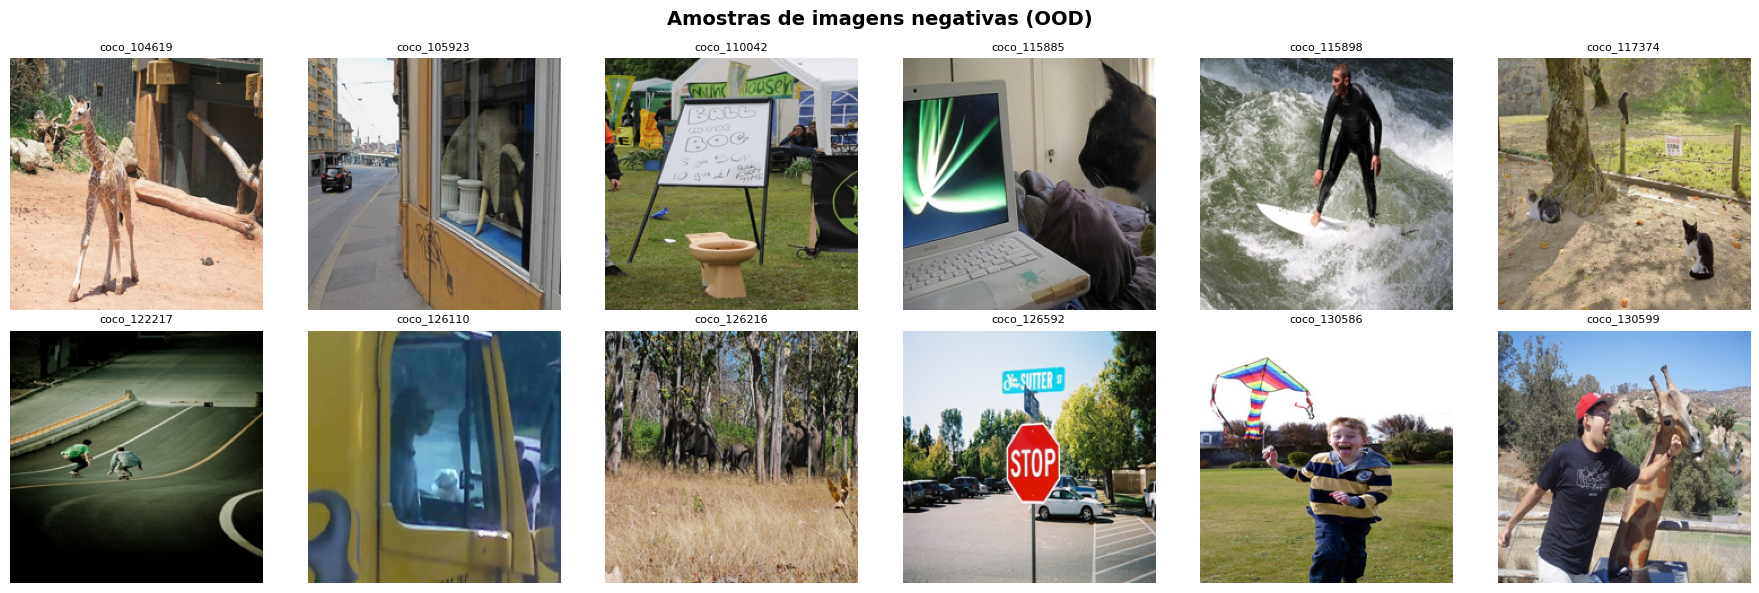

In [6]:
# Visualiza amostras de imagens negativas para confirmar qualidade
neg_imgs = list(NEG_DIR.glob("*.jpg"))[:12] if NEG_DIR.exists() else []

if neg_imgs:
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    fig.suptitle("Amostras de imagens negativas (OOD)", fontsize=14, fontweight="bold")
    for ax, p in zip(axes.flat, neg_imgs):
        try:
            img = Image.open(p).convert("RGB").resize((224, 224))
            ax.imshow(img)
            ax.set_title(p.stem[:15], fontsize=8)
        except Exception:
            ax.set_title("erro", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem negativa encontrada. Execute coletar_negativos.py primeiro.")

## 3. Dataset e DataLoaders

In [7]:
def build_records():
    """Varre os diretórios e retorna lista de {path, label_idx, class_name}."""
    records = []

    # Classes de defeito
    for idx, cls in enumerate(DEFECT_CLASSES):
        d = IMAGES_DIR / cls
        if not d.exists():
            d = IMAGES_DIR / cls.replace("_", " ")
        exts = ["*.jpg", "*.png", "*.bmp", "*.jpeg"]
        imgs = [p for e in exts for p in d.glob(e)] if d.exists() else []
        for p in imgs:
            records.append({"path": p, "label_idx": idx, "class_name": cls})

    # Negativos (OOD)
    neg_imgs = [p for e in ["*.jpg", "*.png"] for p in NEG_DIR.glob(e)] \
               if NEG_DIR.exists() else []
    for p in neg_imgs:
        records.append({"path": p, "label_idx": OOD_CLASS_IDX, "class_name": "negative"})

    random.shuffle(records)
    return records


def stratified_split(records, val_ratio=0.15, test_ratio=0.15):
    labels = [r["label_idx"] for r in records]
    idx    = list(range(len(records)))
    
    idx_tv, idx_test = train_test_split(
        idx, test_size=test_ratio, stratify=labels, random_state=SEED
    )
    labels_tv = [labels[i] for i in idx_tv]
    adj = val_ratio / (1 - test_ratio)
    idx_train, idx_val = train_test_split(
        idx_tv, test_size=adj, stratify=labels_tv, random_state=SEED
    )
    return [records[i] for i in idx_train], [records[i] for i in idx_val], [records[i] for i in idx_test]


records = build_records()
train_recs, val_recs, test_recs = stratified_split(records)

print(f"Train : {len(train_recs):>5} amostras")
print(f"Val   : {len(val_recs):>5} amostras")
print(f"Test  : {len(test_recs):>5} amostras")
print()
print("Distribuição no treino:")
for cls, cnt in Counter(r["class_name"] for r in train_recs).most_common():
    bar = "█" * (cnt // 10)
    print(f"  {cls:<22}: {cnt:>4}  {bar}")

Train :  1980 amostras
Val   :   425 amostras
Test  :   425 amostras

Distribuição no treino:
  silk_spot             :  455  █████████████████████████████████████████████
  negative              :  366  ████████████████████████████████████
  water_spot            :  203  ████████████████████
  welding_line          :  191  ███████████████████
  crescent_gap          :  158  ███████████████
  punching_hole         :  153  ███████████████
  inclusion             :  152  ███████████████
  oil_spot              :  143  ██████████████
  waist_folding         :  102  ██████████
  crease                :   36  ███
  rolled_pit            :   21  ██


In [8]:
class GC10OODDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records   = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        try:
            img = np.array(Image.open(rec["path"]).convert("RGB"))
        except Exception:
            img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, rec["label_idx"]


train_tf = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.4),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(var_limit=(5, 30), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# WeightedRandomSampler para balancear classes desiguais
counts  = Counter(r["label_idx"] for r in train_recs)
weights = [1.0 / counts[r["label_idx"]] for r in train_recs]
sampler = WeightedRandomSampler(weights, num_samples=len(train_recs), replacement=True)

train_ds = GC10OODDataset(train_recs, transform=train_tf)
val_ds   = GC10OODDataset(val_recs,   transform=val_tf)
test_ds  = GC10OODDataset(test_recs,  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Batches treino : {len(train_loader)}")
print(f"Batches val    : {len(val_loader)}")
print(f"Batches test   : {len(test_loader)}")

Batches treino : 62
Batches val    : 14
Batches test   : 14


/tmp/ipykernel_5867/3062510527.py:28: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 30), p=0.3),
/tmp/ipykernel_5867/3062510527.py:29: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),


## 4. Modelo — EfficientNetV2-S com 11 classes

In [9]:
class GC10MultiOutputNet(nn.Module):
    """EfficientNetV2-S com cabeça dupla: classificação (11 classes) + bbox."""
    def __init__(self, num_classes=11):
        super().__init__()
        backbone = efficientnet_v2_s(weights=None)
        in_feat  = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.backbone  = backbone
        self.cls_head  = nn.Sequential(
            nn.Linear(in_feat, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512),    nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.bbox_head = nn.Sequential(
            nn.Linear(in_feat, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512),    nn.ReLU(),
            nn.Linear(512, 4),
            nn.Sigmoid(),
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.cls_head(feat), self.bbox_head(feat)


def load_and_expand_model(checkpoint_path: Path) -> GC10MultiOutputNet:
    """
    Carrega o modelo de 10 classes e expande a última camada para 11.
    Os pesos das 10 classes originais são preservados.
    A linha da classe 'negative' é inicializada com zeros (parte do neutro).
    """
    print(f"Carregando checkpoint: {checkpoint_path}")
    
    # Instancia modelo com 10 classes (igual ao original)
    old_model = GC10MultiOutputNet(num_classes=10)
    old_model.load_state_dict(
        torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    )

    # Novo modelo com 11 classes
    new_model = GC10MultiOutputNet(num_classes=11)
    new_sd    = new_model.state_dict()
    old_sd    = old_model.state_dict()

    for k, v in old_sd.items():
        if k not in new_sd:
            continue
        if new_sd[k].shape == v.shape:
            # Copiar direto — backbone + todas as camadas intermediárias
            new_sd[k] = v
        elif "cls_head.6" in k:
            # Última camada: expande de 10 → 11
            if k.endswith(".weight"):
                new_w = new_sd[k].clone()
                new_w[:10, :] = v      # 10 classes antigas
                new_w[10, :]  = 0.0    # classe negativa — peso zero
                new_sd[k] = new_w
            elif k.endswith(".bias"):
                new_b = new_sd[k].clone()
                new_b[:10] = v
                new_b[10]  = 0.0
                new_sd[k]  = new_b

    new_model.load_state_dict(new_sd)
    print("✅ Pesos expandidos para 11 classes (negative inicializada com zeros).")
    return new_model


if not CHECKPOINT_IN.exists():
    raise FileNotFoundError(
        f"Checkpoint não encontrado: {CHECKPOINT_IN}\n"
        "Coloque gc10det_cls_best.pt na mesma pasta do notebook."
    )

model = load_and_expand_model(CHECKPOINT_IN).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParâmetros totais    : {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")

Carregando checkpoint: gc10det_cls_best.pt
✅ Pesos expandidos para 11 classes (negative inicializada com zeros).

Parâmetros totais    : 23,858,271
Parâmetros treináveis: 23,858,271


## 5. Fine-tuning

In [10]:
# Pesos de classe para CrossEntropy — compensa desbalanceamento
def make_class_weights(train_records):
    counts = Counter(r["label_idx"] for r in train_records)
    total  = sum(counts.values())
    w = torch.zeros(N_CLASSES, dtype=torch.float32)
    for idx, cnt in counts.items():
        w[idx] = total / (N_CLASSES * cnt)
    return w.to(DEVICE)

class_weights = make_class_weights(train_recs)
criterion     = nn.CrossEntropyLoss(weight=class_weights)

# Otimizador com LR diferenciado: backbone menor que a cabeça
backbone_params = list(model.backbone.parameters())
head_params     = list(model.cls_head.parameters()) + list(model.bbox_head.parameters())

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": head_params,     "lr": LR},
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("Configuração de treino:")
print(f"  Épocas       : {EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  LR cabeça    : {LR}")
print(f"  LR backbone  : {LR_BACKBONE}")
print(f"  Weight decay : {WEIGHT_DECAY}")
print(f"  Dispositivo  : {DEVICE}")

Configuração de treino:
  Épocas       : 30
  Batch size   : 32
  LR cabeça    : 0.0002
  LR backbone  : 5e-05
  Weight decay : 0.0001
  Dispositivo  : cuda


In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        cls_out, _ = model(imgs)
        loss = criterion(cls_out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (cls_out.argmax(1) == labels).sum().item()
        n          += labels.size(0)
    return total_loss / len(loader), correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = n = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        cls_out, _ = model(imgs)
        loss     = criterion(cls_out, labels)
        total_loss += loss.item()
        preds     = cls_out.argmax(1)
        correct  += (preds == labels).sum().item()
        n        += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader), correct / n, all_preds, all_labels


# ─── Loop de treinamento ───────────────────────────────────────────────────────
history      = []
best_val_acc = 0.0

print(f"\nIniciando fine-tuning por {EPOCHS} épocas...\n")
print(f"{'Epoch':>6} {'TrLoss':>8} {'VlLoss':>8} {'TrAcc':>7} {'VlAcc':>7}  Saved")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc              = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, preds, lbls = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history.append({
        "epoch": epoch, "tr_loss": tr_loss, "vl_loss": vl_loss,
        "tr_acc": tr_acc, "vl_acc": vl_acc
    })

    saved = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CHECKPOINT_OUT)
        saved = "✓"

    if epoch % 5 == 0 or epoch == 1 or saved:
        print(
            f"{epoch:>6} {tr_loss:>8.4f} {vl_loss:>8.4f} "
            f"{tr_acc*100:>6.1f}% {vl_acc*100:>6.1f}%  {saved}"
        )

print(f"\n✅ Melhor val acc: {best_val_acc*100:.2f}%")
print(f"✅ Modelo salvo em: {CHECKPOINT_OUT}")


Iniciando fine-tuning por 30 épocas...

 Epoch   TrLoss   VlLoss   TrAcc   VlAcc  Saved
----------------------------------------------------
     1   0.8891   0.5745   71.6%   77.4%  ✓
     2   0.4740   0.5497   75.6%   80.9%  ✓
     3   0.4177   0.4551   78.4%   91.8%  ✓
     4   0.3902   0.4769   82.1%   92.7%  ✓
     5   0.3754   0.4693   82.5%   93.9%  ✓
     6   0.3616   0.4137   82.9%   94.4%  ✓
     7   0.3734   0.4413   82.5%   94.8%  ✓
     9   0.3497   0.4637   83.6%   95.3%  ✓
    10   0.3716   0.4839   83.7%   95.1%  
    12   0.3283   0.4833   84.5%   95.5%  ✓
    15   0.3072   0.5234   85.7%   95.3%  
    16   0.2907   0.5230   86.9%   95.8%  ✓
    20   0.2977   0.5429   86.4%   95.3%  
    25   0.2919   0.5057   86.5%   95.1%  
    30   0.2662   0.5263   86.1%   95.1%  

✅ Melhor val acc: 95.76%
✅ Modelo salvo em: gc10det_cls_ood.pt


## 6. Curvas de aprendizado

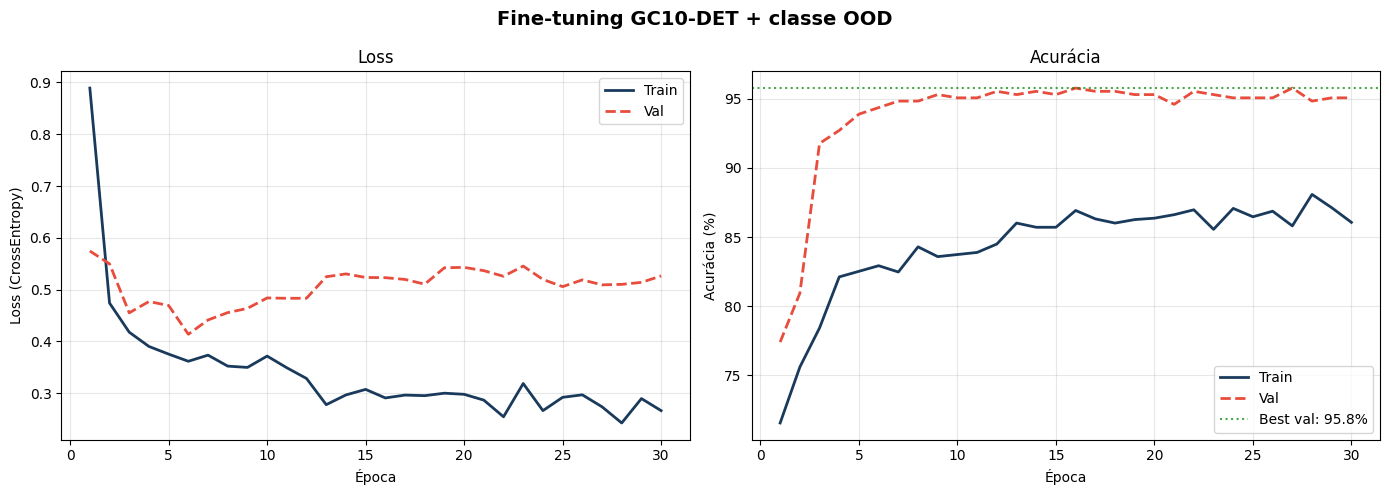

Curvas salvas em training_curves.png


In [12]:
epochs  = [h["epoch"]   for h in history]
tr_loss = [h["tr_loss"] for h in history]
vl_loss = [h["vl_loss"] for h in history]
tr_acc  = [h["tr_acc"]  for h in history]
vl_acc  = [h["vl_acc"]  for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fine-tuning GC10-DET + classe OOD", fontsize=14, fontweight="bold")

ax1.plot(epochs, tr_loss, label="Train", linewidth=2, color="#1a3a5c")
ax1.plot(epochs, vl_loss, label="Val",   linewidth=2, color="#e74c3c", linestyle="--")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss (CrossEntropy)")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, [a * 100 for a in tr_acc], label="Train", linewidth=2, color="#1a3a5c")
ax2.plot(epochs, [a * 100 for a in vl_acc], label="Val",   linewidth=2, color="#e74c3c", linestyle="--")
ax2.axhline(best_val_acc * 100, color="green", linestyle=":", alpha=0.7, label=f"Best val: {best_val_acc*100:.1f}%")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)")
ax2.set_title("Acurácia")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Curvas salvas em training_curves.png")

## 7. Avaliação no conjunto de teste

In [13]:
# Carrega o melhor checkpoint
model.load_state_dict(torch.load(CHECKPOINT_OUT, map_location=DEVICE, weights_only=True))
model.eval()

_, _, test_preds, test_labels = eval_epoch(model, test_loader, criterion)

print("=" * 70)
print("  RELATÓRIO DE CLASSIFICAÇÃO — CONJUNTO DE TESTE")
print("=" * 70)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=3))

  RELATÓRIO DE CLASSIFICAÇÃO — CONJUNTO DE TESTE
               precision    recall  f1-score   support

punching_hole      0.865     0.970     0.914        33
 welding_line      0.947     0.878     0.911        41
 crescent_gap      1.000     0.971     0.985        34
   water_spot      0.977     0.977     0.977        43
     oil_spot      0.967     0.935     0.951        31
    silk_spot      1.000     0.979     0.990        97
    inclusion      0.853     0.906     0.879        32
   rolled_pit      0.625     1.000     0.769         5
       crease      1.000     1.000     1.000         8
waist_folding      1.000     1.000     1.000        22
     negative      1.000     0.975     0.987        79

     accuracy                          0.960       425
    macro avg      0.930     0.963     0.942       425
 weighted avg      0.964     0.960     0.961       425



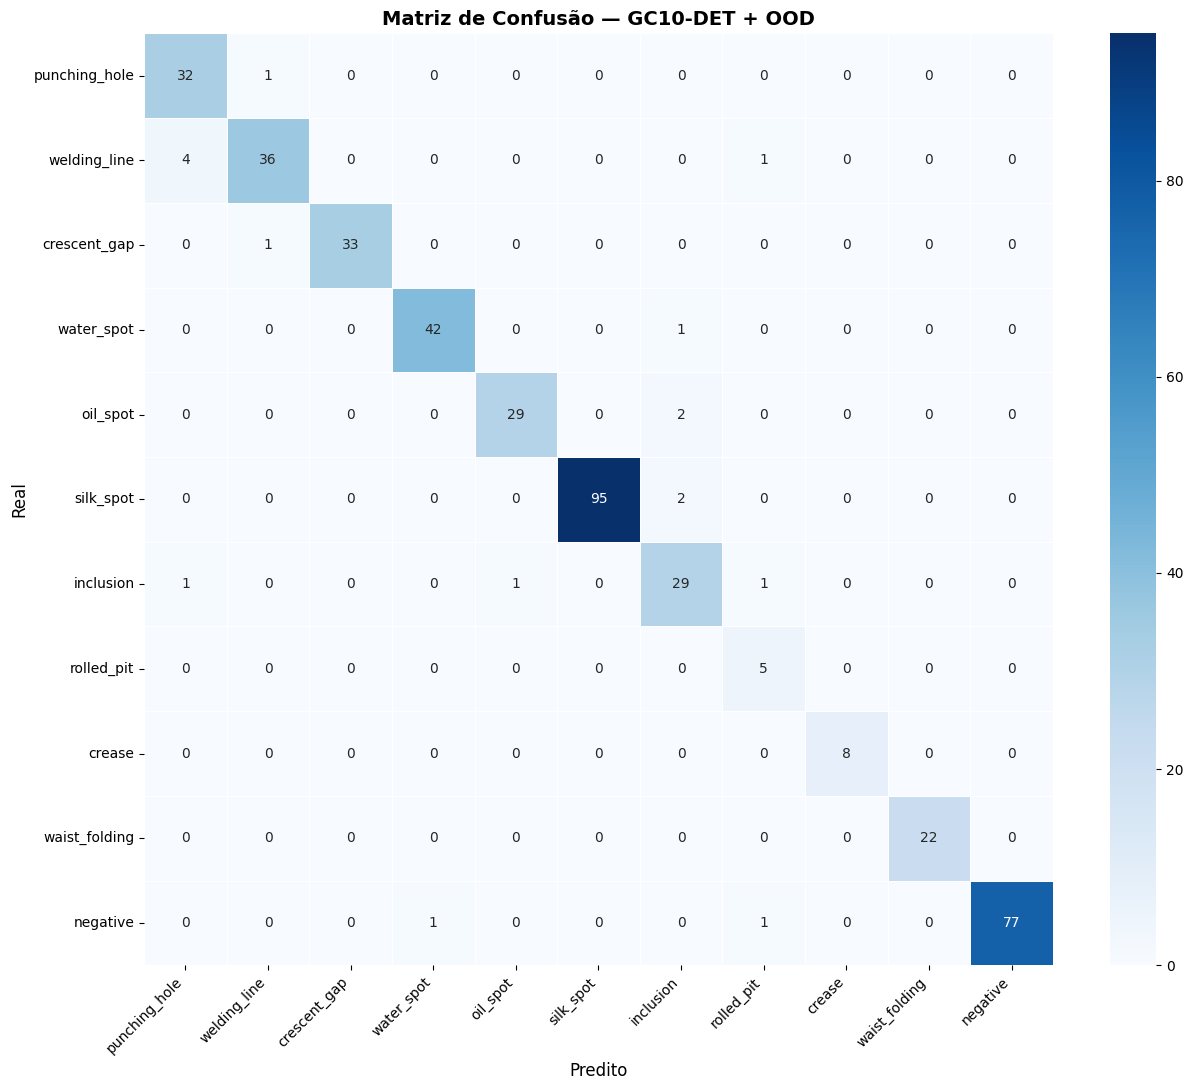


🎯 Classe OOD (negative):
   Verdadeiros Positivos (rejeitou corretamente) : 77
   Falsos Negativos (aceitou indevidamente)      : 2
   Recall OOD                                    : 97.5%


In [14]:
# Matriz de confusão
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5
)
ax.set_xlabel("Predito", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
ax.set_title("Matriz de Confusão — GC10-DET + OOD", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# Destaca erros da classe negative
ood_row  = cm[OOD_CLASS_IDX]
ood_tp   = ood_row[OOD_CLASS_IDX]
ood_fn   = ood_row.sum() - ood_tp
ood_recall = ood_tp / max(ood_row.sum(), 1)

print(f"\n🎯 Classe OOD (negative):")
print(f"   Verdadeiros Positivos (rejeitou corretamente) : {ood_tp}")
print(f"   Falsos Negativos (aceitou indevidamente)      : {ood_fn}")
print(f"   Recall OOD                                    : {ood_recall*100:.1f}%")

## 8. Calibração de limiares por classe

In [15]:
from sklearn.metrics import f1_score

@torch.no_grad()
def calibrate_thresholds(model, loader):
    """Encontra o limiar que maximiza F1 para cada classe individualmente."""
    model.eval()
    all_probs, all_labels = [], []

    for imgs, labels in loader:
        cls_out, _ = model(imgs.to(DEVICE))
        probs = torch.softmax(cls_out, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.extend(labels.tolist())

    all_probs  = np.vstack(all_probs)
    all_labels = np.array(all_labels)

    thresholds = {}
    print(f"{'Classe':<22}  {'Limiar':>7}  {'F1':>6}")
    print("-" * 42)

    for idx, cls in enumerate(CLASS_NAMES):
        binary = (all_labels == idx).astype(int)
        best_t, best_f1 = 0.3, 0.0
        for t in np.arange(0.20, 0.95, 0.05):
            preds = (all_probs[:, idx] >= t).astype(int)
            f1    = f1_score(binary, preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, float(t)
        thresholds[cls] = round(best_t, 2)
        marker = " ← OOD" if cls == "negative" else ""
        print(f"{cls:<22}  {best_t:>7.2f}  {best_f1:>6.3f}{marker}")

    return thresholds


print("Calibrando limiares no conjunto de validação...\n")
thresholds = calibrate_thresholds(model, val_loader)

Calibrando limiares no conjunto de validação...

Classe                   Limiar      F1
------------------------------------------
punching_hole              0.45   0.892
welding_line               0.45   0.916
crescent_gap               0.50   1.000
water_spot                 0.45   0.977
oil_spot                   0.20   0.949
silk_spot                  0.60   0.995
inclusion                  0.35   0.952
rolled_pit                 0.65   0.667
crease                     0.90   0.933
waist_folding              0.20   0.955
negative                   0.20   0.987 ← OOD


## 9. Salvar metadata e testar com imagem de dashboard

In [16]:
# Salva detection_metadata.json
meta = {
    "model_version":  "ood_v1",
    "num_classes":    N_CLASSES,
    "class_names":    CLASS_NAMES,
    "ood_class_idx":  OOD_CLASS_IDX,
    "ood_class_name": "negative",
    "thresholds":     thresholds,
    "ood_threshold":  thresholds.get("negative", 0.40),
    "description": (
        "Se prob[negative] >= ood_threshold, rejeitar como fora do domínio. "
        "Para cada classe de defeito, usar o limiar em 'thresholds'."
    ),
}

META_OUT.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"✅ Metadata salva em: {META_OUT}")
print(f"   Limiar OOD       : {meta['ood_threshold']}")
print(f"   Modelo           : {CHECKPOINT_OUT}")

✅ Metadata salva em: detection_metadata.json
   Limiar OOD       : 0.2
   Modelo           : gc10det_cls_ood.pt


In [17]:
# ─── Teste rápido: classifica imagens da pasta de teste ───────────────────────
from torchvision import transforms as T

infer_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

@torch.no_grad()
def predict_single(img_path: Path) -> dict:
    model.eval()
    img    = Image.open(img_path).convert("RGB")
    tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    cls_out, _ = model(tensor)
    probs  = torch.softmax(cls_out, dim=1)[0].cpu().numpy()

    ood_score = float(probs[OOD_CLASS_IDX])
    is_ood    = ood_score >= meta["ood_threshold"]

    defect_probs = probs[:OOD_CLASS_IDX]
    top_idx   = int(defect_probs.argmax())
    top_label = CLASS_NAMES[top_idx]
    top_score = float(defect_probs[top_idx])

    return {
        "top_label": top_label,
        "top_score": top_score,
        "ood_score": ood_score,
        "is_ood":    is_ood,
        "all_probs": {CLASS_NAMES[i]: float(p) for i, p in enumerate(probs)},
    }


# Testa nas imagens negativas do conjunto de teste
neg_test = [r["path"] for r in test_recs if r["class_name"] == "negative"][:6]

if neg_test:
    print("Teste nas imagens negativas (esperado: is_ood = True)\n")
    for p in neg_test:
        res = predict_single(p)
        status = "✅ REJEITOU" if res["is_ood"] else "❌ FALHOU"
        print(f"{status}  {p.name:<30}  OOD score: {res['ood_score']*100:.1f}%  "
              f"(top defect: {res['top_label']} {res['top_score']*100:.0f}%)")
else:
    print("Nenhuma imagem negativa no conjunto de teste.")

Teste nas imagens negativas (esperado: is_ood = True)

✅ REJEITOU  coco_465806.jpg                 OOD score: 99.9%  (top defect: waist_folding 0%)
✅ REJEITOU  coco_190637.jpg                 OOD score: 100.0%  (top defect: water_spot 0%)
✅ REJEITOU  coco_417043.jpg                 OOD score: 99.9%  (top defect: waist_folding 0%)
✅ REJEITOU  synth__gen_color_gradient_0015.jpg  OOD score: 93.2%  (top defect: waist_folding 2%)
✅ REJEITOU  synth__gen_grid_table_0010.jpg  OOD score: 100.0%  (top defect: waist_folding 0%)
✅ REJEITOU  synth__gen_text_document_0018.jpg  OOD score: 99.8%  (top defect: waist_folding 0%)


## 10. Patch do app.py — como integrar o modelo OOD

Após treinar, aplique as seguintes alterações no `app.py`:

In [18]:
patch = '''
# ─────────────────────────────────────────────────────────────────────────────
# PATCH OOD — alterações necessárias no app.py
# ─────────────────────────────────────────────────────────────────────────────

# 1. Substituir CLS_PATH para apontar para o novo modelo:
#    CLS_PATH = _find_model('gc10det_cls_ood.pt', 'gc10det_cls_best.pt')

# 2. Atualizar CLASS_NAMES para incluir 'negative':
#    CLASS_NAMES = [
#        'punching_hole', 'welding_line', 'crescent_gap', 'water_spot', 'oil_spot',
#        'silk_spot', 'inclusion', 'rolled_pit', 'crease', 'waist_folding',
#        'negative',
#    ]
#    OOD_CLASS_IDX = 10

# 3. Substituir a função classify_image:
def classify_image(pil_img):
    from torchvision import transforms
    meta          = load_meta()
    ood_threshold = meta.get("ood_threshold", 0.40)

    device    = next(cls_model.parameters()).device
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    img_rgb = pil_img.convert('RGB')
    w, h    = img_rgb.size
    tensor  = transform(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        cls_out, bbox_out = cls_model(tensor)

    probs  = torch.softmax(cls_out, dim=1)[0].cpu().numpy()
    bbox_n = bbox_out[0].cpu().numpy()
    x1 = int(bbox_n[0]*w); y1 = int(bbox_n[1]*h)
    x2 = int(bbox_n[2]*w); y2 = int(bbox_n[3]*h)

    ood_score = float(probs[OOD_CLASS_IDX])
    is_ood    = ood_score >= ood_threshold

    defect_probs = probs[:OOD_CLASS_IDX]
    top_idx   = int(defect_probs.argmax())
    top_label = CLASS_NAMES[top_idx]
    top_score = float(defect_probs[top_idx])

    all_probs = sorted(
        [{'label': CLASS_NAMES[i], 'score': float(p)} for i, p in enumerate(probs)],
        key=lambda x: -x['score'],
    )

    return {
        'top_label': top_label,
        'top_score': top_score,
        'all_probs': all_probs,
        'cls_bbox':  [x1, y1, x2, y2],
        'ood_score': ood_score,   # NOVO
        'is_ood':    is_ood,      # NOVO
    }

# 4. No bloco de exibição (col_res), ANTES do bloco de classificação, adicionar:
# if cls_result.get('is_ood'):
#     st.error(
#         f"⛔ Imagem fora do domínio industrial — "
#         f"score OOD: {cls_result['ood_score']*100:.1f}%\\n"
#         "Esta imagem não parece ser uma chapa de aço. A detecção foi bloqueada."
#     )
#     st.stop()   # bloqueia o restante da análise
# ─────────────────────────────────────────────────────────────────────────────
'''

patch_path = BASE_DIR / "app_ood_patch.txt"
patch_path.write_text(patch, encoding="utf-8")
print("✅ Instruções de integração salvas em app_ood_patch.txt")
print()
print("Próximos passos:")
print("  1. Use gc10det_cls_ood.pt no lugar de gc10det_cls_best.pt")
print("  2. Aplique as alterações descritas em app_ood_patch.txt")
print("  3. Reinicie o Streamlit: streamlit run app.py")

✅ Instruções de integração salvas em app_ood_patch.txt

Próximos passos:
  1. Use gc10det_cls_ood.pt no lugar de gc10det_cls_best.pt
  2. Aplique as alterações descritas em app_ood_patch.txt
  3. Reinicie o Streamlit: streamlit run app.py
